# 2D elastic registration
CDullin 2025

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from skimage import io 
# import xpit_module as xm
import xpit_module2 as xm
importlib.reload(xm)
import warnings
warnings.filterwarnings('ignore')
%matplotlib notebook

#### Declarations
if masks are not wanted define the name as None

In [15]:
# declaration
fixed_file = "E://Data//ghost//elastic_reg//652//652_ct_patch1.tif"
moving_file = "E://Data//ghost//elastic_reg//652/652_histo_patch1.tif"

fixed_mask_file = None
moving_mask_file = None

#### Loading all data and preparing it for a mutual information based registration
if the input has color channels the average is used to calculate the registration, while the transformation is then applied on the color images again

In [16]:
# load
FC = io.imread(fixed_file).astype('float')
MC = io.imread(moving_file).astype('float')

if np.ndim(FC)==3:
    F = np.average(FC,axis=2)
else:
    F=FC
    
if np.ndim(MC)==3:
    #M = np.average(MC,axis=2)
    M = MC[:,:,0]
else:
    M = MC

F=F/np.max(F)*50.0
M=M/np.max(M)*50.0

if fixed_mask_file==None:
    FM = np.ones((F.shape[0],F.shape[1]))
else:
    FM = np.array(io.imread(fixed_mask_file)>128).astype('int')

if moving_mask_file==None:
    MM = np.ones((M.shape[0],M.shape[1]))
else:
    MM = np.array(io.imread(moving_mask_file)>128).astype('int')

#### Quick visualization if the correct data has been loaded

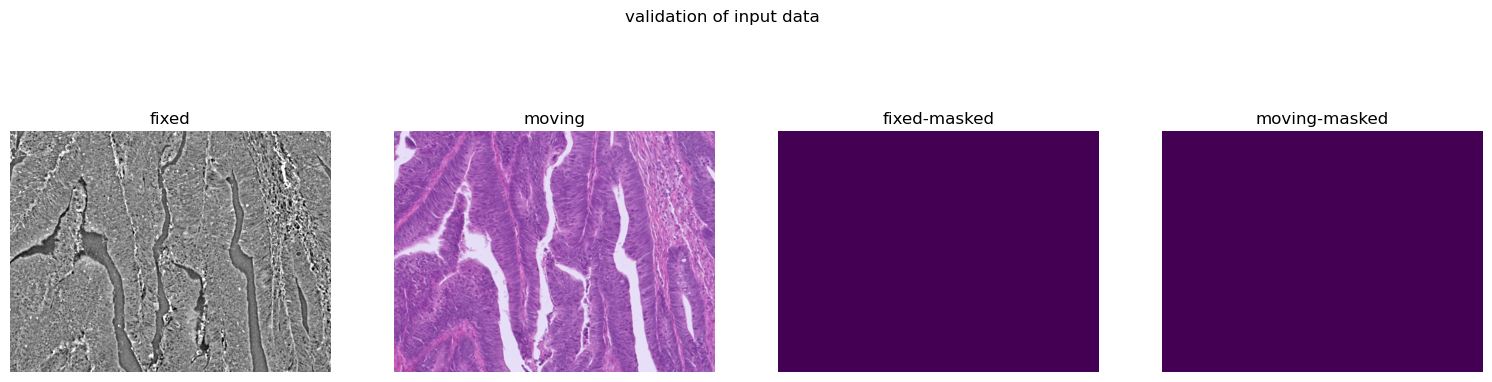

F = (475, 631)
M = (475, 631)


In [17]:
moving_image = io.imread(moving_file)

%matplotlib inline
# show input
plt.figure(figsize=(19,5))
ax=plt.subplot(141)
ax.imshow(F, cmap='gray')
ax.axis('off')
ax.set_title('fixed')
ax=plt.subplot(142)
ax.imshow(moving_image)
ax.axis('off')
ax.set_title('moving')
ax=plt.subplot(143)
ax.imshow(FM*255)
ax.axis('off')
ax.set_title('fixed-masked')
ax=plt.subplot(144)
ax.imshow(MM*255)
ax.axis('off')
ax.set_title('moving-masked')
plt.suptitle('validation of input data')
plt.show()

print('F =',F.shape)
print('M =',M.shape)

#### Start of the elastic registration
the registration is performed on 3 scale levels

In [18]:
%matplotlib notebook 
print('do spline registration')
final_spline_transform,spline_aligned_image,jacobian = xm.bspline_registration(F,M,FM,MM, max_iter=500)

do spline registration


B-Spline Registration Progress Level [3]:   0%|          | 0/100 [00:00<?, ?it/s]

Final Metric Value: -0.3631163082564713
Optimizer Iterations: 134
Final metric value: -0.3631163082564713
Optimizer's stopping condition, LBFGSBOptimizerv4: Function tolerance reached after 134 iterations. The relative reduction of the cost function <= 2.22045e-09 = CostFunctionConvergenceFactor (1e+07) * machine precision (2.22045e-16).


#### Display and export registration result

Saving deformed images as  E:\Data\ghost\elastic_reg\652\652_histo_patch1_registered.tif
Saving checkerboard as  E:\Data\ghost\elastic_reg\652\652_histo_patch1_registered_checkerboard.png
Saving image with deformed lines as E:\Data\ghost\elastic_reg\652\652_histo_patch1_registered_checkerboard_lines.png


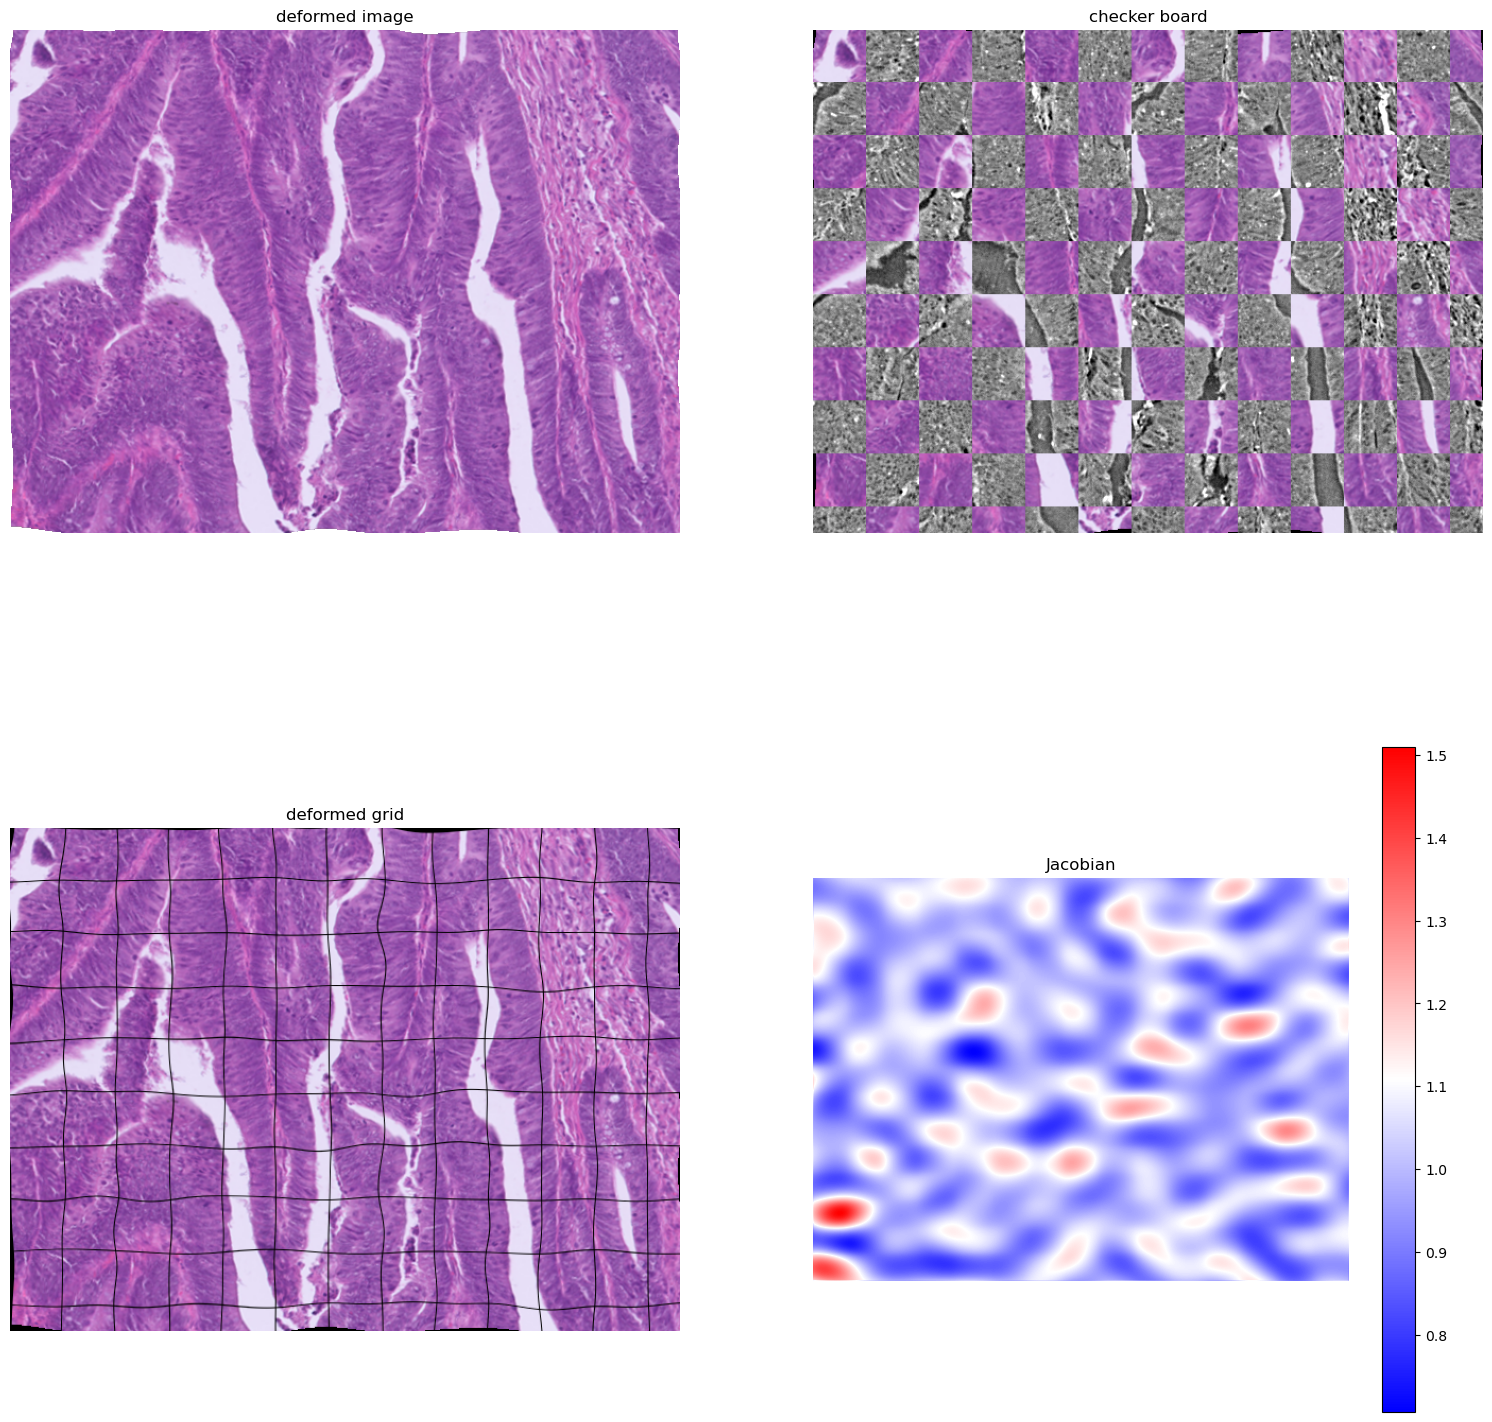

In [19]:
%matplotlib inline
export_base_file_name = "E:\\Data\\ghost\\elastic_reg\\652\\652_histo_patch1_registered.tif"
xm.display_and_export_registration(fixed_file,moving_file,final_spline_transform,jacobian,export_base_file_name,checkers=50,lines=50)

In [14]:
import SimpleITK as sitk

In [15]:
transformed_image = sitk.GetArrayFromImage(spline_aligned_image)

In [16]:
transformed_image.shape

(522, 562)

#### [Optional] Calculate registration quality
Keep in mind that the DICE and Jaccard strongly depend on the segmentation, Cross-Entropy not

<IPython.core.display.Javascript object>


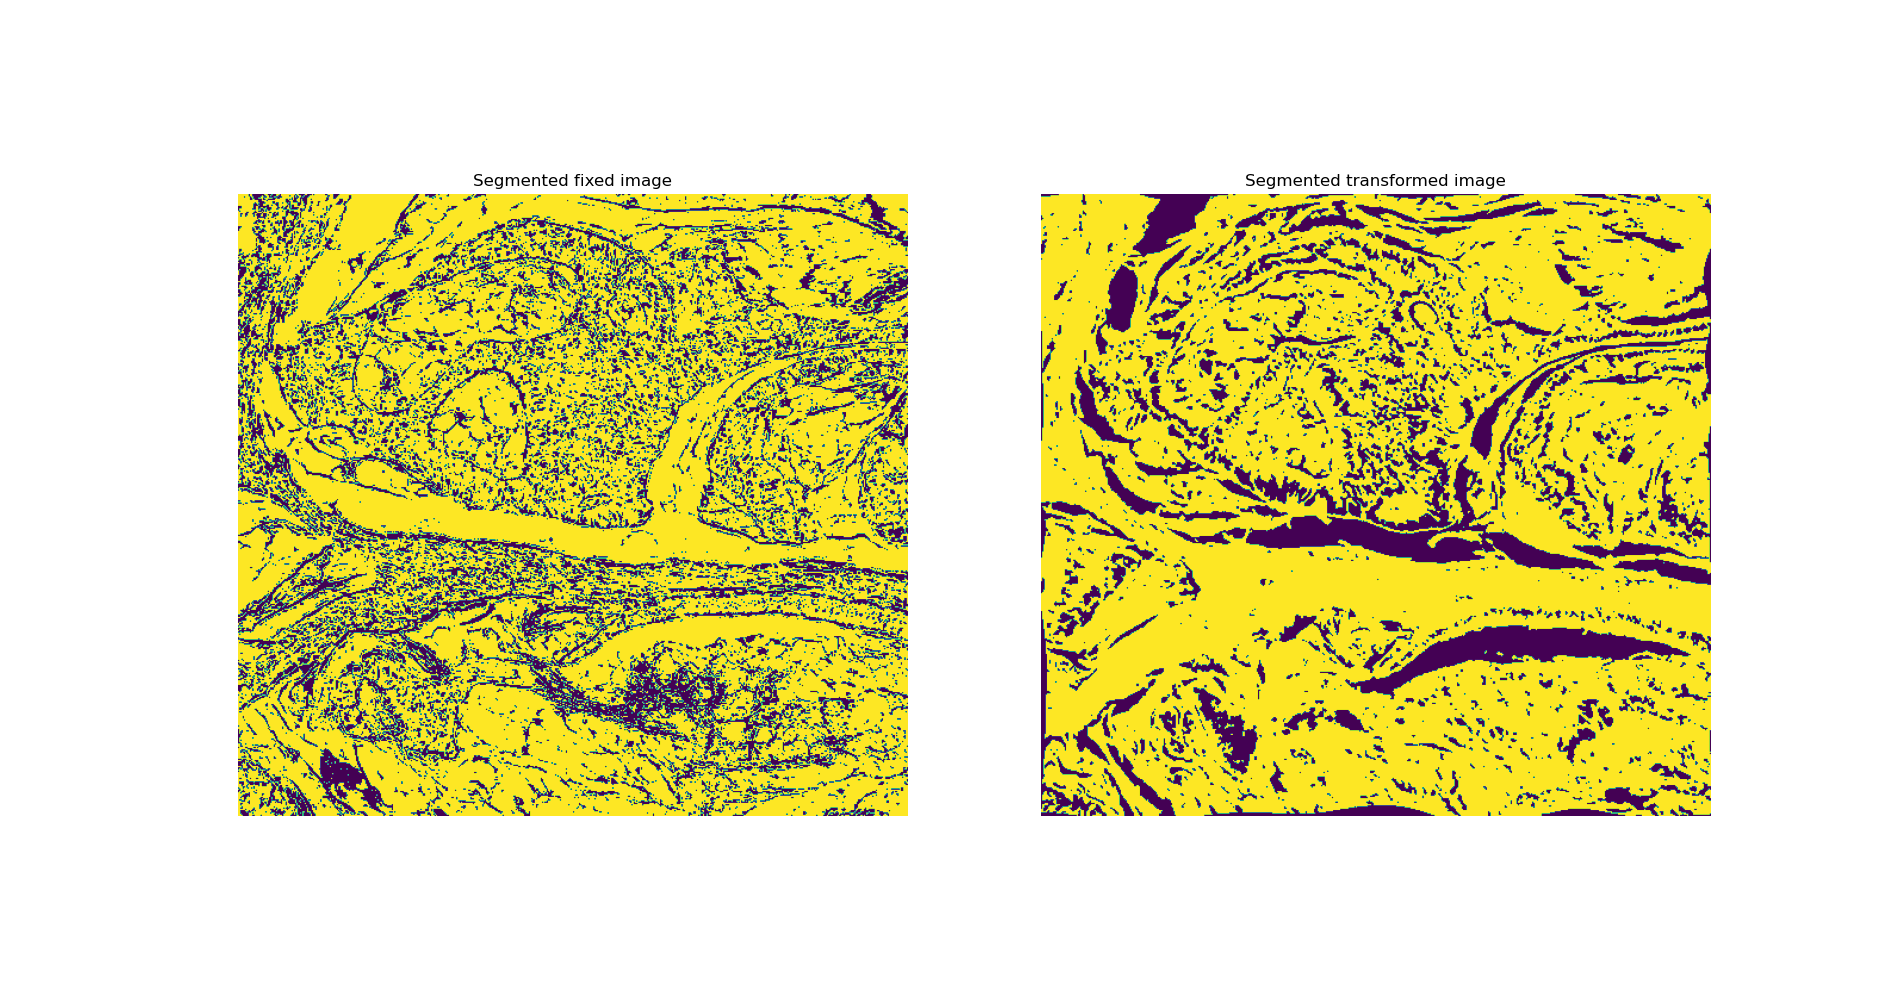

{'Dice': 0.7499646769907039, 'Jaccard': 0.599954787825725, 'Normalized Cross Entropy': 0.08288774179213508}


In [10]:
print(xm.registration_quality(F,spline_aligned_image,l_threshold_fixed=0.35,h_threshold_fixed=0.6,
                              l_threshold_moving=0.5,h_threshold_moving=.90,Verbose=True))